In [ ]:
# 1. Download the dataset file (.zip)
!wget -q https://github.com/kuldeepstechwork/Face-Expression-Recognition-using-Deep-Learning/archive/refs/heads/master.zip

# 2. Unzip it silently into your Colab workspace
!unzip -q master.zip

In [ ]:
import json
import os

# Your Kaggle username (the name shown in your Kaggle profile URL)
# Replace 'your_username' with your actual Kaggle handle
KAGGLE_USERNAME = "SarthakSB"

# Your exact new API token string
KAGGLE_KEY = "KGAT_f97b46b7be5c99ed3c57a9ea30aa0e20"

# Create the hidden folder where the system expects it
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Write the token configuration directly to the background file
token_data = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(token_data, f)

# Set correct security permissions
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print("Kaggle configurations built successfully from string!")

Kaggle configurations built successfully from string!


In [ ]:
# 1. Download the facial expression dataset
!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset

# 2. Extract the actual image files
!unzip -q face-expression-recognition-dataset.zip

# 3. Clean up the large zip file to free space
!rm face-expression-recognition-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset
License(s): unknown
100% 121M/121M [00:01<00:00, 67.2MB/s]



In [ ]:
import os

# Set paths to the newly extracted image folders
train_dir = '/content/images/train'
validation_dir = '/content/images/validation'

print("Train path exists:", os.path.exists(train_dir))
print("Validation path exists:", os.path.exists(validation_dir))

Train path exists: True
Validation path exists: True


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data_dir = '/kaggle/input/face-expression-recognition-dataset/images'
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. FORCE the correct Google Colab paths right here
train_dir = '/content/images/train'
validation_dir = '/content/images/validation'

# 2. Initialize your generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# 3. Stream the images from the forced paths
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode='grayscale'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


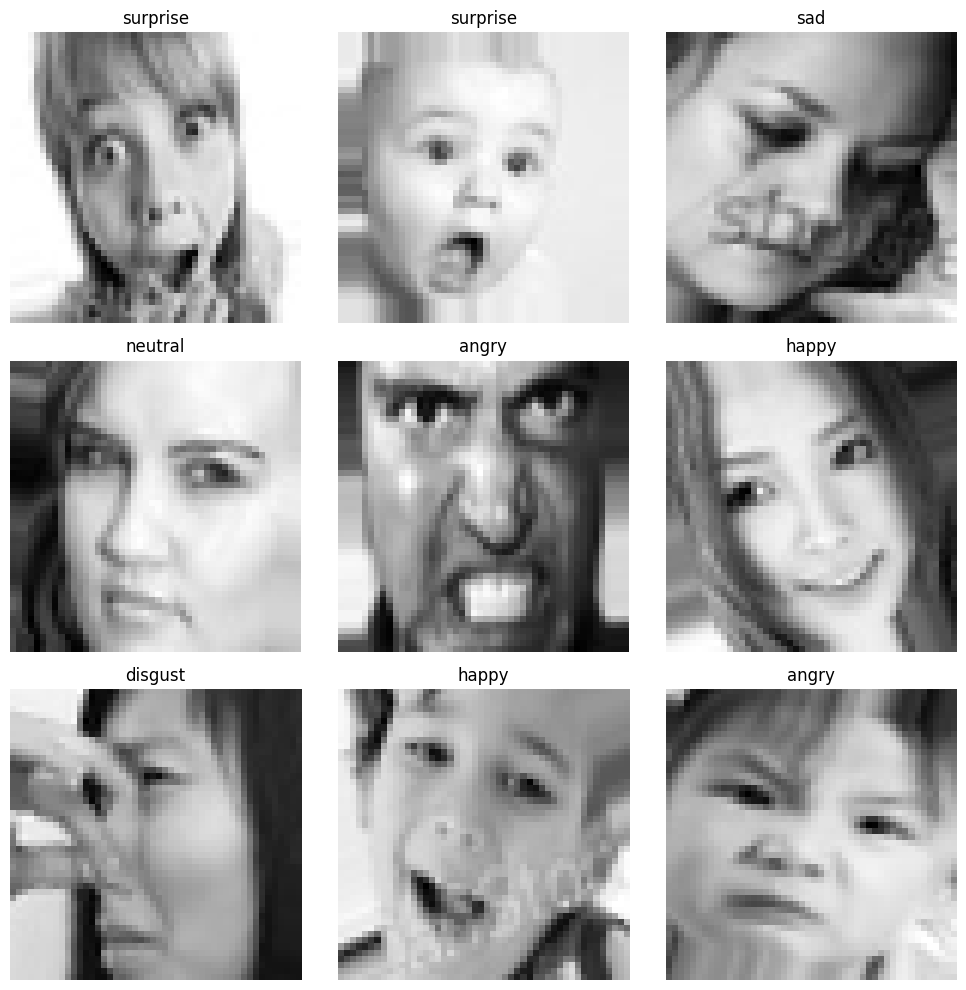

In [ ]:
#EDA
class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].reshape(48, 48), cmap='gray')
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# CNN Model Architecture
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,474,759 (9.44 MB)

 Trainable params: 2,472,839 (9.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# Model Training
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 414s 910ms/step - accuracy: 0.2865 - loss: 2.0694 - val_accuracy: 0.2345 - val_loss: 2.1006 - learning_rate: 0.0010
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 419s 928ms/step - accuracy: 0.3912 - loss: 1.6073 - val_accuracy: 0.4411 - val_loss: 1.4792 - learning_rate: 0.0010
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 420s 931ms/step - accuracy: 0.4401 - loss: 1.4594 - val_accuracy: 0.4975 - val_loss: 1.3093 - learning_rate: 0.0010
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 427s 947ms/step - accuracy: 0.4673 - loss: 1.3945 - val_accuracy: 0.4932 - val_loss: 1.3372 - learning_rate: 0.0010
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 414s 918ms/step - accuracy: 0.4812 - loss: 1.3612 - val_accuracy: 0.4803 - val_loss: 1.3119 - learning_rate: 0.0010
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 421s 934ms/step - accuracy: 0.4896 - loss: 1.3334 - val_accuracy: 0.5616 - val_loss: 1.1627 - learning_rate: 0.0010
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 418s 926ms/step - accura

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step
              precision    recall  f1-score   support

       angry       0.36      0.80      0.50         5
     disgust       1.00      0.33      0.50         3
        fear       1.00      0.19      0.32        16
       happy       0.86      0.86      0.86        14
     neutral       0.20      0.50      0.29         4
         sad       0.50      0.70      0.58        10
    surprise       0.73      0.67      0.70        12

    accuracy                           0.58        64
   macro avg       0.66      0.58      0.53        64
weighted avg       0.74      0.58      0.57        64



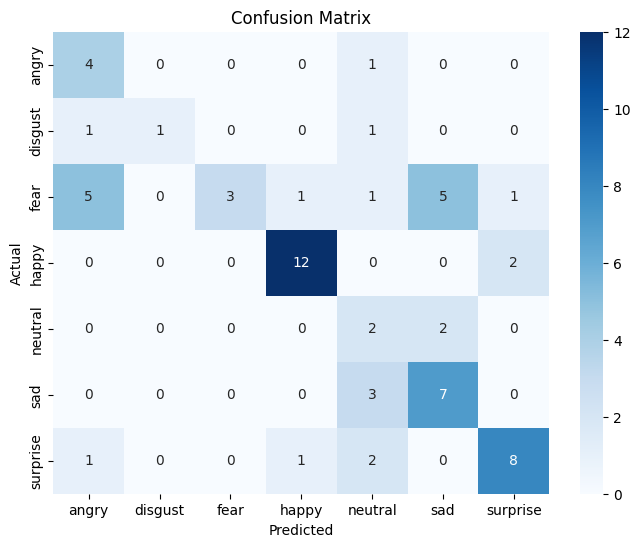

In [ ]:
# 6. Evaluation - Classification Report & Confusion Matrix
val_images, val_labels = next(validation_generator)
predictions = model.predict(val_images)
y_true = np.argmax(val_labels, axis=1)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def detect_emotion(image_path):
    img = image.load_img(image_path, target_size=(48, 48), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = round(prediction[0][predicted_index] * 100, 2)  # Confidence in %

    # Display the image with the predicted label and confidence
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted Emotion: {predicted_class} ({confidence}%)')
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


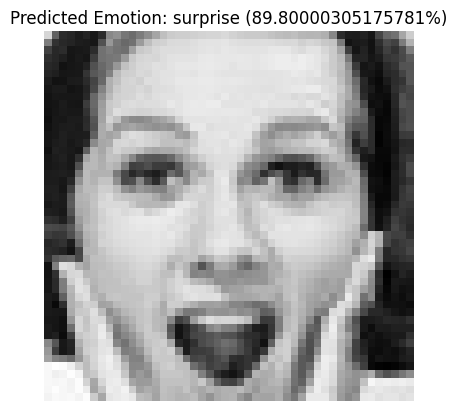

Emotion: surprise, Confidence: 89.80000305175781%


In [ ]:
# Example Detection
predicted_emotion, confidence = detect_emotion('/content/images/train/surprise/10011.jpg')
print(f"Emotion: {predicted_emotion}, Confidence: {confidence}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


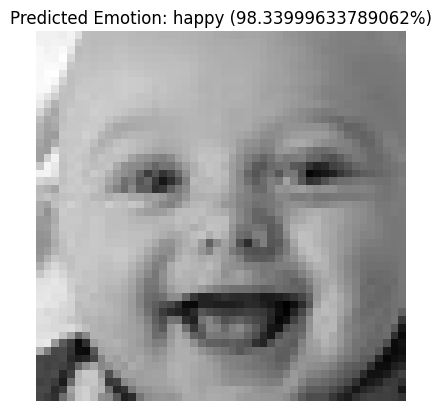

('happy', np.float32(98.34))


In [ ]:
# Example Detection
print(detect_emotion('/content/images/train/happy/10005.jpg'))

In [27]:
#Saving the model

In [29]:
# Save the model architecture, weights, and optimizer state natively in HDF5 format
model.save("facial_emotion_model.h5")
print("Model successfully exported as 'facial_emotion_model.h5'!")

Model successfully exported as 'facial_emotion_model.h5'!


In [30]:
from google.colab import files
files.download('facial_emotion_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>